# PCA on Real Data

**This notebook is self-contained; it recaps the PCA recipe before scaling it up.**

With the 2D intuition in hand, this notebook turns PCA loose on a real table of house sales and compresses many columns down to a couple of components. It is the capstone that ties Unit 2 together, covariance, eigenvectors, and projection doing real work, and it exposes the one practical trap that ruins PCA in the wild: **forgetting to standardize.**

## Learning objectives

- Prepare a wide numeric table for PCA and explain why **standardizing** matters.
- Read a **scree plot** to choose how many components to keep.
- Interpret component **loadings** and a 2D projection.

## Background

The recipe from the previous notebook, unchanged: center the data, build the covariance matrix, take its eigenvectors (the **principal components**), and read the eigenvalues as variance explained.

The one new wrinkle is **units**. Covariance depends on scale, so a column measured in tens of thousands (lot area in square feet) contributes vastly more raw variance than one measured in single digits (a 1 to 10 quality score), regardless of which is actually more informative. **Standardizing** each column first,

$$z = \frac{x - \bar{x}}{s},$$

puts every feature on a common footing: mean 0, standard deviation 1. Then PCA is run on the **correlation** structure rather than the raw covariance, and the components mean something.

## This notebook covers

1. Load the table; a 7-column subset small enough to read.
2. The covariance matrix, printed, and the scale problem it reveals.
3. PCA **without** standardizing: PC1 is meaningless.
4. PCA **with** standardizing: PC1 becomes "how big is the house."
5. Scree plot, loadings, and a 2D projection.

**Prerequisites:** `U2-7_PCA-1_Intuition`

**Dataset:** `Real Estate Data.csv` (Ames housing), from the shared dataset library via `helpers.data(...)`.
**References:** `sklearn.decomposition.PCA`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plotting helper: label the axis ends compactly (for grids of small panels)
def label_axes(ax, x='x', y='y', size=8):
    ax.set_xlabel(x, loc='right', fontsize=size)
    ax.set_ylabel(y, loc='top', rotation=0, fontsize=size)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## 1. The data

The table has 68 columns of mixed types. We keep seven numeric ones, enough to be genuinely multi-dimensional, few enough that the covariance matrix can be printed and read.

The same file is used by Unit 3's regression notebooks, so the story continues there.

In [2]:
homes = pd.read_csv(helpers.data('Real Estate/Real Estate Data.csv'), index_col=0)
homes = homes.rename(columns={'OvQual': 'Overall Qual', 'Built': 'Year Built'})

cols = ['Lot Area', 'Overall Qual', 'Year Built', 'Basement Area',
        '1st Floor Area', 'Living Area Above Grade', 'Sale Price']
X = homes[cols].dropna()
print(f"{X.shape[0]} houses, {X.shape[1]} features")
X.head()

1404 houses, 7 features


,Lot Area,Overall Qual,Year Built,Basement Area,1st Floor Area,Living Area Above Grade,Sale Price
Id,,,,,,,
1,8450,7,2003,856,856,1710,208500
2,9600,6,1976,1262,1262,1262,181500
3,11250,7,2001,920,920,1786,223500
4,9550,7,1915,756,961,1717,140000
5,14260,8,2000,1145,1145,2198,250000


In [3]:
# the scale problem, in one table: these columns are not remotely comparable
X.describe().loc[['mean', 'std', 'min', 'max']].round(1)

,Lot Area,Overall Qual,Year Built,Basement Area,1st Floor Area,Living Area Above Grade,Sale Price
mean,10638.5,6.1,1972.2,1071.8,1172.6,1532.8,183919.2
std,10126.7,1.4,29.9,436.2,388.2,522.3,79236.0
min,1300.0,1.0,1875.0,0.0,334.0,334.0,34900.0
max,215245.0,10.0,2010.0,6110.0,4692.0,5642.0,755000.0


Look at the standard deviations in that table. They differ by **orders of magnitude**, `Lot Area` is measured in square feet and runs into five figures, while `Overall Qual` is a 1 to 10 rating. That gap says nothing about which feature matters more; it is purely a statement about the units each happens to be recorded in.

PCA maximizes variance. Handed these columns raw, it will simply find whichever one is measured in the biggest numbers.

## 2. PCA without standardizing: the trap

Run the exact procedure from the previous notebook on the raw columns and look at what PC1 turns out to be.

In [4]:
X_centered = X.values - X.values.mean(axis=0)
Sigma_raw = np.cov(X_centered.T)

vals_raw, vecs_raw = np.linalg.eigh(Sigma_raw)
order = np.argsort(vals_raw)[::-1]
vals_raw, vecs_raw = vals_raw[order], vecs_raw[:, order]
for k in range(vecs_raw.shape[1]):
    if vecs_raw[np.argmax(np.abs(vecs_raw[:, k])), k] < 0:
        vecs_raw[:, k] *= -1

print(f"PC1 explains {vals_raw[0] / vals_raw.sum():.1%} of the raw variance\n")

# what PC1 is actually made of, biggest contribution first
by_size = sorted(zip(cols, vecs_raw[:, 0]), key=lambda p: -abs(p[1]))
for name, w in by_size:
    print(f"   {name:<26} {w:+.4f}")
print(f"\n-> PC1 is dominated by '{by_size[0][0]}', "
      f"the column measured in the largest raw units")

PC1 explains 98.5% of the raw variance

   Sale Price                 +0.9994
   Lot Area                   +0.0332
   Living Area Above Grade    +0.0046
   Basement Area              +0.0033
   1st Floor Area             +0.0029
   Year Built                 +0.0002
   Overall Qual               +0.0000

-> PC1 is dominated by 'Sale Price', the column measured in the largest raw units


PC1 has collapsed onto **whichever column carries the largest raw numbers**, named in the printout above, with every other feature rounded away to almost nothing.

This is not a discovery about houses. It is an artifact of the units. Run this way, PCA has told us only which column happens to be measured on the biggest scale.

## 3. PCA with standardizing

Standardize every column to mean 0 and standard deviation 1, then repeat. Now each feature enters on equal terms, and PC1 has to earn its place by capturing *shared* structure.

In [5]:
Z = StandardScaler().fit_transform(X.values)
print("after standardizing — means ~0, std ~1:")
print(pd.DataFrame(Z, columns=cols).describe().loc[['mean', 'std']].round(3).to_string())

Sigma_z = np.cov(Z.T)
helpers.show(np.round(Sigma_z, 2), label="correlation matrix (standardized covariance)")

after standardizing — means ~0, std ~1:
      Lot Area  Overall Qual  Year Built  Basement Area  1st Floor Area  Living Area Above Grade  Sale Price
mean      -0.0          -0.0        -0.0            0.0            -0.0                      0.0        -0.0
std        1.0           1.0         1.0            1.0             1.0                      1.0         1.0


<IPython.core.display.Math object>

With standardized columns the covariance matrix *is* the correlation matrix: 1s down the diagonal, and every off-diagonal entry between $-1$ and $1$. Reading it, `1st Floor Area`, `Living Area Above Grade`, `Basement Area`, `Overall Qual`, and `Sale Price` are all strongly positively correlated, big, high-quality houses sell for more. `Lot Area` is only weakly related to the rest.

That block of mutually correlated columns is what PCA will collapse into a single component.

In [6]:
vals, vecs = np.linalg.eigh(Sigma_z)
order = np.argsort(vals)[::-1]
vals, vecs = vals[order], vecs[:, order]
explained = vals / vals.sum()

# same sign convention as the previous notebook: largest loading positive
for k in range(vecs.shape[1]):
    if vecs[np.argmax(np.abs(vecs[:, k])), k] < 0:
        vecs[:, k] *= -1

for k in range(len(vals)):
    print(f"PC{k+1}: eigenvalue {vals[k]:5.3f}   {explained[k]:6.1%} of variance"
          f"   (cumulative {explained[:k+1].sum():5.1%})")

# sklearn does the same thing in one line -- check it agrees
p = PCA().fit(Z)
print("\nsklearn agrees on variance explained?",
      np.allclose(p.explained_variance_ratio_, explained))

PC1: eigenvalue 3.817    54.5% of variance   (cumulative 54.5%)
PC2: eigenvalue 1.143    16.3% of variance   (cumulative 70.8%)
PC3: eigenvalue 0.738    10.5% of variance   (cumulative 81.3%)
PC4: eigenvalue 0.717    10.2% of variance   (cumulative 91.6%)
PC5: eigenvalue 0.270     3.9% of variance   (cumulative 95.4%)
PC6: eigenvalue 0.173     2.5% of variance   (cumulative 97.9%)
PC7: eigenvalue 0.147     2.1% of variance   (cumulative 100.0%)

sklearn agrees on variance explained? True


## 4. The scree plot: how many components to keep?

A **scree plot** shows the variance explained by each component in order. You look for the point where the curve flattens, beyond it, extra components are adding little.

The cumulative curve answers the practical question directly: how many components to reach 90% of the information?

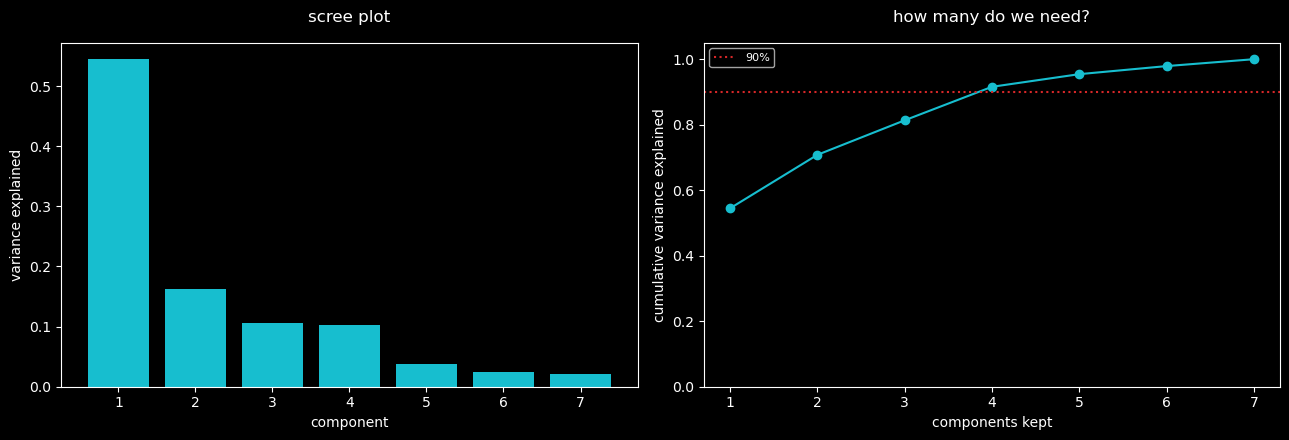

4 components carry 90% of the variance in these 7 features


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ks = np.arange(1, len(vals) + 1)

axes[0].bar(ks, explained, color="tab:cyan")
axes[0].set_xlabel("component")
axes[0].set_ylabel("variance explained")
axes[0].set_title("scree plot", pad=15)

axes[1].plot(ks, np.cumsum(explained), "o-", color="tab:cyan")
axes[1].axhline(0.9, color="tab:red", ls=":", label="90%")
axes[1].set_xlabel("components kept")
axes[1].set_ylabel("cumulative variance explained")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=8)
axes[1].set_title("how many do we need?", pad=15)
plt.tight_layout()
plt.show()

need = int(np.argmax(np.cumsum(explained) >= 0.9) + 1)
print(f"{need} components carry 90% of the variance in these {len(cols)} features")

## 5. What do the components mean?

A component's **loadings** are its entries, how much each original feature contributes. Reading them is how a component gets a name.

In [8]:
loadings = pd.DataFrame(vecs[:, :3], index=cols, columns=['PC1', 'PC2', 'PC3']).round(3)
loadings

,PC1,PC2,PC3
Lot Area,0.172,0.676,-0.385
Overall Qual,0.423,-0.326,-0.256
Year Built,0.295,-0.556,0.003
Basement Area,0.416,0.140,0.570
1st Floor Area,0.413,0.272,0.495
Living Area Above Grade,0.385,0.156,-0.390
Sale Price,0.462,-0.097,-0.254


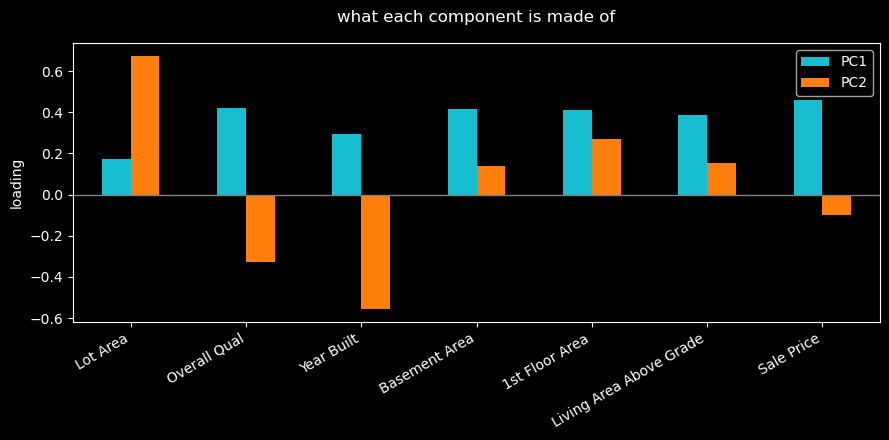

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
loadings[['PC1', 'PC2']].plot.bar(ax=ax, color=["tab:cyan", "tab:orange"])
ax.axhline(0, color="gray", lw=1)
ax.set_ylabel("loading")
ax.set_title("what each component is made of", pad=15)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**PC1** loads positively and fairly evenly on living area, first-floor area, basement area, overall quality, and sale price. That is a single interpretable idea: **"how big and expensive is this house."** One number now summarizes five correlated columns.

**PC2** is dominated by `Lot Area` and `Year Built`, the features PC1 ignored. It separates *old houses on big lots* from *new houses on small ones*, which is a genuinely different axis of variation from sheer size.

This is what "latent factor" means: nobody recorded a column called "house size," but it was implicit in five columns at once, and PCA recovered it.

## 6. The projection

Finally, plot every house by its first two component scores. Two numbers per house, down from seven, carrying most of the variance, and coloring by sale price shows the compression kept what matters.

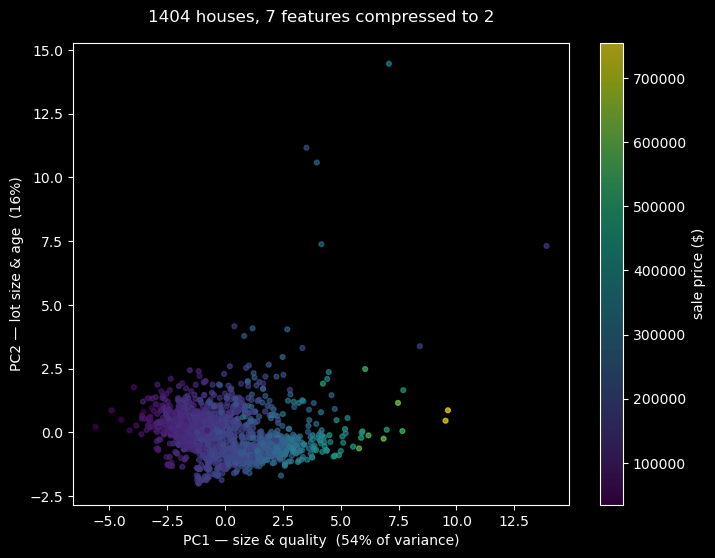

In [10]:
scores = Z @ vecs[:, :2]

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(scores[:, 0], scores[:, 1], c=X['Sale Price'].values,
                s=12, alpha=0.65, cmap="viridis")
fig.colorbar(sc, ax=ax, label="sale price ($)")
ax.set_xlabel(f"PC1 — size & quality  ({explained[0]:.0%} of variance)")
ax.set_ylabel(f"PC2 — lot size & age  ({explained[1]:.0%})")
ax.set_title("1404 houses, 7 features compressed to 2", pad=15)
plt.show()

Price rises smoothly left to right, along PC1, exactly as the loadings predicted. The vertical axis carries the lot-size-and-age variation, which is close to independent of price.

Note that we never told PCA about sale price as a target; it is just another correlated column. The structure it found is the structure that was in the data.

In [11]:
# how much did we actually lose? rebuild from 2 components and compare
rebuilt = scores @ vecs[:, :2].T
error = np.mean((Z - rebuilt) ** 2)
print(f"features per house: 7  ->  2")
print(f"variance retained : {explained[:2].sum():.1%}")
print(f"mean squared reconstruction error (standardized units): {error:.4f}")
print(f"which equals the discarded eigenvalues / n_features:    {vals[2:].sum() / len(cols):.4f}")

features per house: 7  ->  2
variance retained : 70.8%
mean squared reconstruction error (standardized units): 0.2920
which equals the discarded eigenvalues / n_features:    0.2922


## 7. Summary

- **Standardize first.** On raw columns PCA just finds whichever feature has the biggest units: here it returned `Sale Price` and told us nothing.
- On standardized data the covariance matrix **is** the correlation matrix, and its eigenvectors are the principal components.
- A **scree plot** shows where the returns flatten; the cumulative curve says how many components reach a chosen threshold.
- **Loadings** name a component: read off its largest entries. For this table PC1 gathers the size-and-quality columns and PC2 the lot-size-and-age ones: latent factors nobody recorded directly. Another table gives different factors; the *reading* is the transferable skill.
- Two components replaced seven features while keeping most of the variance, and the reconstruction error is exactly the eigenvalues that were dropped.

**That closes Unit 2.** The path was: systems → vectors → matrices → transformations → determinants → eigenvalues → PCA, and the capstone used every step. The same table returns in Unit 3's regression notebooks, where sale price becomes something to *predict* rather than describe.

Next unit, **calculus**, which opens by asking how wrong an approximation is allowed to be
(`U3-1_Approximation-1_ModelsAndError`).